In [1]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv("melb_data.csv")

In [8]:
df.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
7873,Footscray,7/75 Droop St,2,u,360000.0,PI,McGrath,20/05/2017,6.4,3011.0,...,1.0,1.0,761.0,NaN,NaN,Maribyrnong,-37.79530,144.89570,Western Metropolitan,7570.0
13382,Burwood,3 Aylwin Av,3,h,1220000.0,VB,Noel,26/08/2017,10.4,3125.0,...,2.0,2.0,261.0,151.0,2015.0,NaN,-37.84691,145.10029,Southern Metropolitan,5678.0
8956,Strathmore,2/30 Bulla Rd,2,h,646000.0,S,Nelson,1/07/2017,8.2,3041.0,...,1.0,1.0,184.0,NaN,1990.0,Moonee Valley,-37.74040,144.90835,Western Metropolitan,3284.0
4994,Preston,1/46 Tyler St,2,h,520000.0,S,Barry,25/02/2017,8.8,3072.0,...,1.0,2.0,178.0,NaN,2012.0,Darebin,-37.73310,145.03410,Northern Metropolitan,14577.0
4315,Niddrie,2 Kelvin Cl,4,h,1080000.0,S,Nelson,17/09/2016,11.2,3042.0,...,3.0,2.0,539.0,162.0,1976.0,Moonee Valley,-37.74440,144.88470,Western Metropolitan,2291.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [12]:
df.shape

(13580, 21)

In [13]:
(df.isnull().mean()*100).sort_values(ascending=False)

BuildingArea     47.496318
YearBuilt        39.580265
CouncilArea      10.081001
Car               0.456554
Suburb            0.000000
Bathroom          0.000000
Regionname        0.000000
Longtitude        0.000000
Lattitude         0.000000
Landsize          0.000000
Bedroom2          0.000000
Address           0.000000
Postcode          0.000000
Distance          0.000000
Date              0.000000
SellerG           0.000000
Method            0.000000
Price             0.000000
Type              0.000000
Rooms             0.000000
Propertycount     0.000000
dtype: float64

In [14]:
# will work on numerical data
# so removing CouncilArea (categorical column)

In [15]:
num_cols = [
    'Rooms',
    'Distance',
    'Postcode',
    'Bedroom2',
    'Bathroom',
    'Car',
    'Landsize',
    'BuildingArea',
    'YearBuilt',
    'Propertycount',
    'Price'
]

In [16]:
df[num_cols].isnull().sum()

Rooms               0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
Propertycount       0
Price               0
dtype: int64

<h4>Relations</h4>
<pre>
BuildingArea ↔ Rooms, Bathroom, Landsize
YearBuilt ↔ BuildingArea, Price
Car ↔ Rooms, BuildingArea
</pre>

In [17]:
corr_matrix = df[num_cols].corr(numeric_only=True)

corr_matrix[['BuildingArea','YearBuilt','Car']].sort_values(
    by='BuildingArea',
    ascending=False
)

,BuildingArea,YearBuilt,Car
BuildingArea,1.000000,0.019665,0.096101
Landsize,0.500485,0.036451,0.026770
Rooms,0.124127,-0.065413,0.408483
Bedroom2,0.122319,-0.053319,0.405325
Bathroom,0.111933,0.152702,0.322246
Distance,0.099481,0.246379,0.262994
Car,0.096101,0.104515,1.000000
Price,0.090981,-0.323617,0.238979
Postcode,0.055475,0.032863,0.050289
YearBuilt,0.019665,1.000000,0.104515


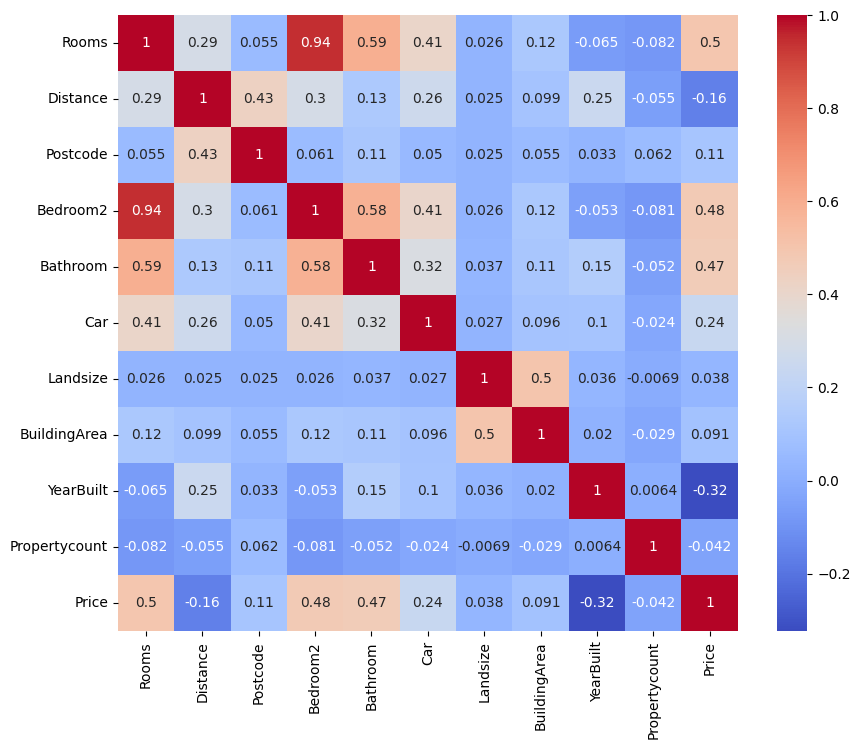

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.show()

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# here i will make baseline data using median imputation

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = df[num_cols].drop('Price',axis=1)
y = df['Price']

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [27]:
si = SimpleImputer(strategy='median')
X_train_med = si.fit_transform(X_train)
X_test_med = si.transform(X_test)

In [26]:
from sklearn.impute import SimpleImputer

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [29]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_med,y_train)
pred = rf.predict(X_test_med)
print(mean_absolute_error(y_test,pred))

180071.68274541557


In [30]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [31]:
ii = IterativeImputer(random_state=42,max_iter=20)

In [32]:
X_train_itr = ii.fit_transform(X_train)
X_test_itr = ii.transform(X_test)

In [33]:
rf = RandomForestRegressor(random_state=42)

In [34]:
rf.fit(X_train_itr,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
pred_itr = rf.predict(X_test_itr)

In [36]:
print(mean_absolute_error(y_test,pred_itr))

181628.25088715012


In [37]:
df[['BuildingArea','Rooms','Bathroom','Landsize']].corr()

,BuildingArea,Rooms,Bathroom,Landsize
BuildingArea,1.000000,0.124127,0.111933,0.500485
Rooms,0.124127,1.000000,0.592934,0.025678
Bathroom,0.111933,0.592934,1.000000,0.037130
Landsize,0.500485,0.025678,0.037130,1.000000


In [38]:
df[num_cols].corr()['BuildingArea'].sort_values(ascending=False)

BuildingArea     1.000000
Landsize         0.500485
Rooms            0.124127
Bedroom2         0.122319
Bathroom         0.111933
Distance         0.099481
Car              0.096101
Price            0.090981
Postcode         0.055475
YearBuilt        0.019665
Propertycount   -0.028840
Name: BuildingArea, dtype: float64

In [39]:
df[num_cols].corr()['YearBuilt'].sort_values(ascending=False)

YearBuilt        1.000000
Distance         0.246379
Bathroom         0.152702
Car              0.104515
Landsize         0.036451
Postcode         0.032863
BuildingArea     0.019665
Propertycount    0.006361
Bedroom2        -0.053319
Rooms           -0.065413
Price           -0.323617
Name: YearBuilt, dtype: float64

In [40]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [41]:
si = SimpleImputer(strategy='median')

In [42]:
X_train_med = si.fit_transform(X_train)
X_test_med = si.transform(X_test)

In [43]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_med, y_train)
pred_med = rf.predict(X_test_med)
mae_med = mean_absolute_error(y_test, pred_med)
print(mae_med)

180071.68274541557


In [44]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [45]:
ii = IterativeImputer(random_state=42,max_iter=20)

In [46]:
X_train_itr = ii.fit_transform(X_train)
X_test_itr = ii.transform(X_test)

In [47]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_itr, y_train)
pred_itr = rf.predict(X_test_itr)
mae_itr = mean_absolute_error(y_test, pred_itr)
print(mae_itr)

181628.25088715012


In [49]:
pd.DataFrame({'Original': X_train['BuildingArea'],'Iterative': X_train_itr[:, list(X.columns).index('BuildingArea')]})

,Original,Iterative
12796,160.0,160.000000
9642,NaN,222.997118
3207,NaN,-4.770062
1698,76.0,76.000000
761,NaN,162.981820
...,...,...
5191,NaN,-162.578974
13418,93.0,93.000000
5390,NaN,563.304417
860,79.0,79.000000


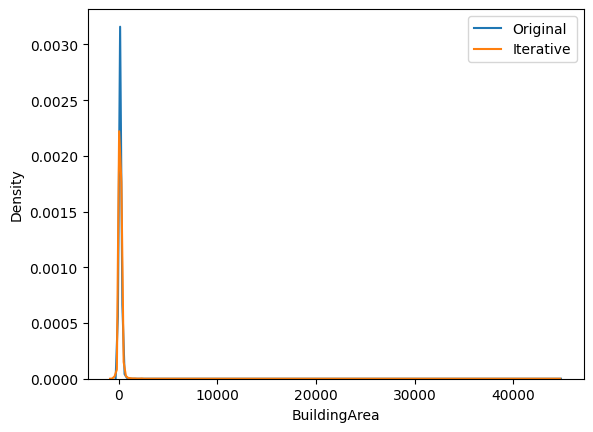

In [50]:
import seaborn as sns

sns.kdeplot(X_train['BuildingArea'], label='Original')
sns.kdeplot(pd.Series(X_train_itr[:, list(X.columns).index('BuildingArea')]),label='Iterative')
plt.legend()
plt.show()